# Libraries

In [ ]:
# !pip install qiskit==2.4.1 qiskit-aer==0.17.2
# from getpass import getpass
# token = getpass("GitHub token: ")
# !git clone https://{token}@github.com/srazzetti/statistical-qst-vae.git
# %cd statistical-qst-vae/notebook

fatal: destination path 'statistical-qst-vae' already exists and is not an empty directory.
/content/statistical-qst-vae/notebook


In [2]:
import tensorflow as tf
import keras
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import sys
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix
import sklearn
from sklearn.model_selection import train_test_split
import time
import os
from datetime import datetime
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("/Users/riccardoruggeri/project-sda/statistical-qst-vae")
RESULTS_ROOT = PROJECT_ROOT / "results"

In [3]:
sys.path.append('../src')
from povm_sampling import *
from statesprep import *
from vae import *
from plots import *
from utils import *

# Data Creation and Processing

In [13]:
# Create a GHZ state and compute the corresponding density matrix
n_samples = 1000
n_qubits = 3
qc = create_ghz_state(n_qubits)
rho = DensityMatrix(qc)

# Compute the probability distribution over the outcomes of the POVM measurement and sample from it
prob = povm_probability_efficient(rho.data, n_qubits)
sample = sample_povm(prob, n_samples=n_samples)
P_empirical = samples_to_empirical_dist(sample, n_qubits)

# Convert the samples to one-hot encoding
onehot_sample = samples_to_onehot(sample, n_qubits)

In [14]:
# Split the data into training and testing sets (unsupervised: no labels, no stratify)
X_train, X_test = train_test_split(onehot_sample, test_size=0.2, random_state=42)

print(f"Training set size and shape: {len(X_train)} and {X_train.shape}")
print(f"Testing set size and shape: {len(X_test)} and {X_test.shape}")

Training set size and shape: 800 and (800, 12)
Testing set size and shape: 200 and (200, 12)


# Train

In [3]:
def set_up_training(experiment_id = 'run', drive_path = RESULTS_ROOT):
    timestamp = datetime.now().strftime("%m%d_%H%M")
    run_dir = os.path.join(drive_path, f"{experiment_id}_{timestamp}")
    os.makedirs(run_dir, exist_ok=True)

    checkpoint_path = os.path.join(run_dir, "best_weights.weights.h5")
    history_path    = os.path.join(run_dir, "history.csv")

    print(f"All saved in: {run_dir}")

    return run_dir, checkpoint_path, history_path

In [16]:
# Define useful parameters for the VAE training
LATENT_DIM = 16
HIDDEN_DIM = 96
WARMUP_EPOCHS = 50
TOTAL_EPOCHS = 200
BATCH_SIZE = 100
LEARNING_RATE = 1e-3
BETA_MAX = 0.85

In [17]:
# Instantiate and compile the VAE model
vae = VAE(n_qubits=n_qubits, latent_dim=LATENT_DIM, hidden=HIDDEN_DIM)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))
vae.build(input_shape=(None, 4*n_qubits))
model = vae

In [18]:
# Compute the exact probability distribution over the POVM outcomes
P_exact = povm_probability_efficient(rho.data, n_qubits)

# Define callbacks for training
callbacks = [
    KLWarmup(beta_max=BETA_MAX, warmup_epochs=WARMUP_EPOCHS),
    EarlyStopping(monitor='val_reconstruction_loss', mode='min',
                  patience=40, restore_best_weights=True, 
                  start_from_epoch=WARMUP_EPOCHS),
    ReduceLROnPlateau(monitor='val_reconstruction_loss', mode='min',
                      factor=0.5, patience=20, min_lr=1e-6),
]

# fit data
history = model.fit(
    X_train, X_train,
    epochs=TOTAL_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, X_test),
    callbacks=callbacks,
    verbose=1,
)

# save results
run_dir, checkpoint_path, history_path = set_up_training(experiment_id='vae_training')
model.save_weights(checkpoint_path)
pd.DataFrame(history.history).to_csv(history_path, index=False)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - kl_loss: 0.3742 - kl_weight: 0.0000e+00 - loss: 4.0655 - reconstruction_loss: 4.0655 - val_kl_loss: 0.4245 - val_loss: 4.1069 - val_reconstruction_loss: 4.1069 - learning_rate: 0.0010
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_loss: 0.6890 - kl_weight: 0.0170 - loss: 4.0132 - reconstruction_loss: 4.0015 - val_kl_loss: 0.7774 - val_loss: 3.9489 - val_reconstruction_loss: 3.9357 - learning_rate: 0.0010
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_loss: 1.2745 - kl_weight: 0.0340 - loss: 3.7802 - reconstruction_loss: 3.7368 - val_kl_loss: 1.4098 - val_loss: 3.7505 - val_reconstruction_loss: 3.7025 - learning_rate: 0.0010
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_loss: 2.4166 - kl_weight: 0.0510 - loss: 3.4709 - reconstruction_loss: 3.3477 - val_kl_loss: 2.6982 - val_loss: 3.3493 - val_reconstruction_loss: 3.2117 - learning_rate: 0.0010
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_loss: 4.2316 - kl

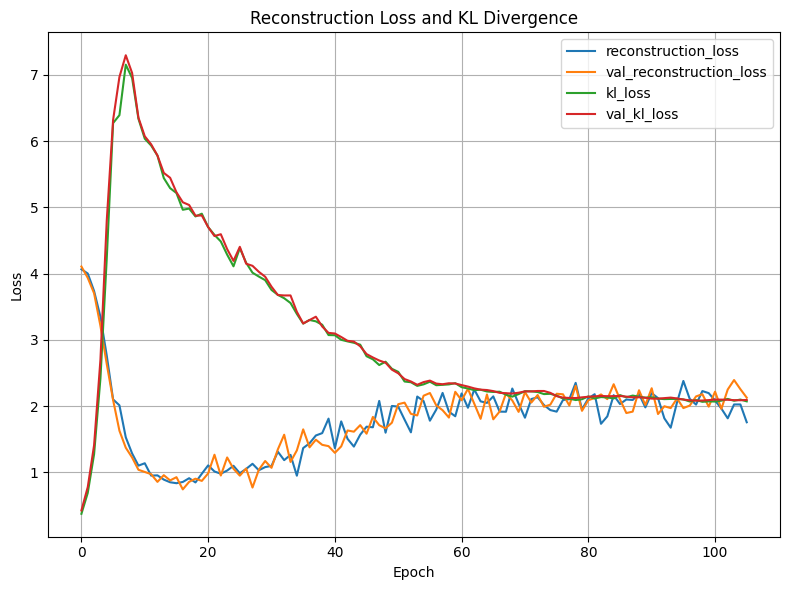

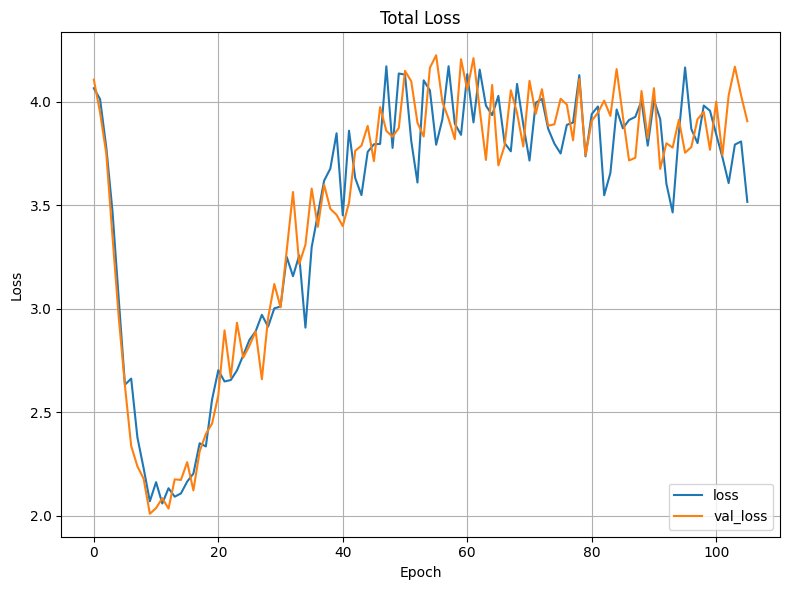

In [19]:
# Plot the training and validation loss curves
plot_reconstruction_and_kl_divergence(history)
plot_total_loss(history)

# Validation: distribuzione generata vs POVM vera

=== Classical Fidelity ===
  uniform  vs true : 0.9510   <- FLOOR
  VAE              vs true : 0.9791   <- MODEL
  training data    vs true : 0.9860   <- BASELINE

=== GHZ 4 Peaks ===
  outcome            true      VAE   uniform
  (0, 0, 0)      0.0625000 0.0539040 0.0156250
  (1, 1, 1)      0.0339279 0.0280200 0.0156250
  (2, 2, 2)      0.0339279 0.0262200 0.0156250
  (3, 3, 3)      0.0339279 0.0160720 0.0156250


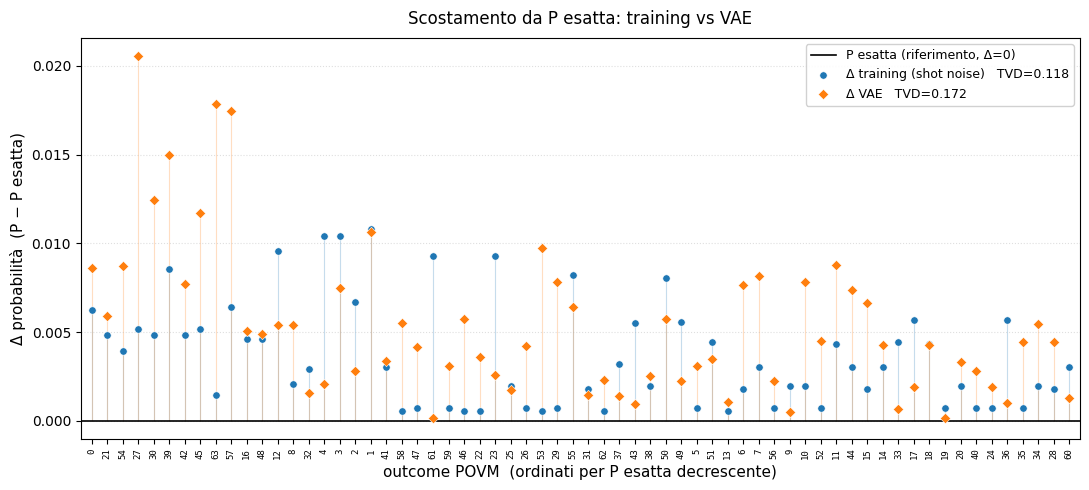

In [22]:
from povm_sampling import onehot_to_samples

# Calculate the exact probability distribution over the POVM outcomes (P_exact)
P_exact = povm_probability_efficient(rho.data, n_qubits)
outcomes = list(P_exact.keys())

# Generate a large number of samples from the trained VAE model to estimate the distribution it has learned (P_vae)
# Convert the one-hot encoded training data back to samples and compute the empirical distribution (P_train)
P_vae   = model.generate_empirical_dist(n_samples=1000000, batch_size=50_000)
P_unif = {o: 1.0 / len(outcomes) for o in outcomes}
P_train = samples_to_empirical_dist(onehot_to_samples(X_train, n_qubits), n_qubits)

# Compute the classical fidelity between the distributions
classical_fidelity_floor = classical_fidelity(P_unif, P_exact)
classical_fidelity_vae = classical_fidelity(P_vae, P_exact)
classical_fidelity_train = classical_fidelity(P_train, P_exact)

print("=== Classical Fidelity ===")
print(f"  uniform  vs true : {classical_fidelity_floor:.4f}   <- FLOOR")
print(f"  VAE              vs true : {classical_fidelity_vae:.4f}   <- MODEL")
print(f"  training data    vs true : {classical_fidelity_train:.4f}   <- BASELINE\n")

print("=== GHZ 4 Peaks ===")
print(f"  {'outcome':14s} {'true':>8s} {'VAE':>8s} {'uniform':>9s}")
for o in [(c,) * n_qubits for c in range(4)]:
    print(f"  {str(o):14s} {P_exact[o]:8.7f} {P_vae.get(o, 0):8.7f} {1/len(outcomes):9.7f}")

# Plot the distributions (P_exact, P_vae, P_train) over the outcomes
p_true = np.array([P_exact[o]        for o in outcomes])
p_gen  = np.array([P_vae.get(o, 0.0) for o in outcomes]) 
p_train = np.array([P_train.get(o, 0.0) for o in outcomes])
idx = np.arange(len(outcomes))

# Default abs=True
plot_distribution_delta(p_true, p_gen, p_train, idx)


# Provo da 3 a 8 qubit

In [7]:
from povm_sampling import onehot_to_samples

N_SAMPLES = [500, 1000, 5000, 10000, 20000, 50000]
N_QUBITS = [3, 4, 5]

# geometria (latent_dim, hidden, N_GEN) per numero di qubit
CFG = {
    3: dict(latent_dim=16,  hidden=96,  batch_size=100, N_GEN=20000),
    4: dict(latent_dim=32,  hidden=128,  batch_size=200, N_GEN=100000),
    5: dict(latent_dim=64,  hidden=224,  batch_size=500, N_GEN=4**5 * 500),
    #6: dict(latent_dim=256, hidden=1280, batch_size=600, N_GEN=4**6 * 500),
    #7: dict(latent_dim=512, hidden=1504, batch_size=800, N_GEN=4**7 * 500),
    #8: dict(latent_dim=512, hidden=2560, batch_size=1000, N_GEN=4**8 * 500),
}

# accumulo i risultati per il plot finale: una curva per ogni numero di qubit
results = {q: {"n_samples": [], "Fc": [], "Fc_train": []} for q in N_QUBITS}

for q in N_QUBITS:
    # GHZ esatto + distribuzione POVM vera
    qc = create_ghz_state(q)
    rho = DensityMatrix(qc)
    P_exact = povm_probability_efficient(rho.data, q)
    outcomes = list(P_exact.keys())            # ricalcolato per ogni q (era un bug: restava a 3 qubit)

    for n in N_SAMPLES:
        print(f"\n=== N_QUBITS={q}   N_SAMPLES={n} ===")
        n_samples = n

        # campiona la distribuzione e prepara i dati
        sample = sample_povm(P_exact, n_samples=n_samples)
        onehot_sample = samples_to_onehot(sample, q)
        X_train, X_test = train_test_split(onehot_sample, test_size=0.2, random_state=42)

        cfg = CFG[q]
        latent_dim, hidden, batch_size, N_GEN = cfg["latent_dim"], cfg["hidden"], cfg["batch_size"], cfg["N_GEN"]

        vae = VAE(n_qubits=q, latent_dim=latent_dim, hidden=hidden)
        vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
        vae.build(input_shape=(None, 4 * q))
        model = vae

        WARMUP = 30   # epoche di warm-up della KL (0 -> beta_max)
        callbacks = [
            KLWarmup(beta_max=0.85, warmup_epochs=WARMUP),
            EarlyStopping(monitor='reconstruction_loss', mode='min',
                            patience=35, restore_best_weights=True, start_from_epoch=WARMUP),
        ]

        history = model.fit(
            X_train, X_train,
            epochs=200,
            batch_size=batch_size,
            validation_data=(X_test, X_test),
            callbacks=callbacks,
            verbose=0,
        )

        # save results
        drive_path = RESULTS_ROOT / "run_5"
        run_dir, checkpoint_path, history_path = set_up_training(experiment_id='vae_training_q{}_n{}'.format(q, n), drive_path = drive_path)
        model.save_weights(checkpoint_path)
        pd.DataFrame(history.history).to_csv(history_path, index=False)

        # campiona dal VAE e calcola le metriche vs la distribuzione esatta
        P_vae   = vae.generate_empirical_dist(n_samples=N_GEN, batch_size=50_000)
        P_train = samples_to_empirical_dist(onehot_to_samples(X_train, q), q)

        Fc        = classical_fidelity(P_vae,   P_exact)
        Fc_train  = classical_fidelity(P_train, P_exact)

        # Print with minimal informations
        print(f"  Fidelity classica VAE vs esatta : {Fc:.4f}   <- MODELLO")
        print(f"  Fidelity classica training vs esatta : {Fc_train:.4f}   <- TETTO")

        # salvo la fidelity classica per il plot al variare di N_SAMPLES e N_QUBITS
        # (atteso: cresce con n_samples, cala con n_qubits)
        results[q]["n_samples"].append(n)
        results[q]["Fc"].append(Fc)
        results[q]["Fc_train"].append(Fc_train)

    print("\nRESULTS:", results)

# Save results to a CSV file for later analysis and plotting
results_df = pd.DataFrame({
    "n_qubits": np.repeat(N_QUBITS, len(N_SAMPLES)),
    "n_samples": np.tile(N_SAMPLES, len(N_QUBITS)),
    "Fc": [results[q]["Fc"][i] for q in N_QUBITS for i in range(len(N_SAMPLES))],
    "Fc_train": [results[q]["Fc_train"][i] for q in N_QUBITS for i in range(len(N_SAMPLES))],
})

# Save the results to a CSV file for later analysis and plotting PROJECT_ROOT
results_df.to_csv(drive_path / "vae_training_results.csv", index=False)



=== N_QUBITS=3   N_SAMPLES=500 ===
All saved in: /Users/riccardoruggeri/project-sda/statistical-qst-vae/results/run_5/vae_training_q3_n500_0611_1838
  Fidelity classica VAE vs esatta : 0.9747   <- MODELLO
  Fidelity classica training vs esatta : 0.9741   <- TETTO

=== N_QUBITS=3   N_SAMPLES=1000 ===
All saved in: /Users/riccardoruggeri/project-sda/statistical-qst-vae/results/run_5/vae_training_q3_n1000_0611_1838
  Fidelity classica VAE vs esatta : 0.9772   <- MODELLO
  Fidelity classica training vs esatta : 0.9860   <- TETTO

=== N_QUBITS=3   N_SAMPLES=5000 ===
All saved in: /Users/riccardoruggeri/project-sda/statistical-qst-vae/results/run_5/vae_training_q3_n5000_0611_1839
  Fidelity classica VAE vs esatta : 0.9891   <- MODELLO
  Fidelity classica training vs esatta : 0.9980   <- TETTO

=== N_QUBITS=3   N_SAMPLES=10000 ===
All saved in: /Users/riccardoruggeri/project-sda/statistical-qst-vae/results/run_5/vae_training_q3_n10000_0611_1839
  Fidelity classica VAE vs esatta : 0.9925   <-

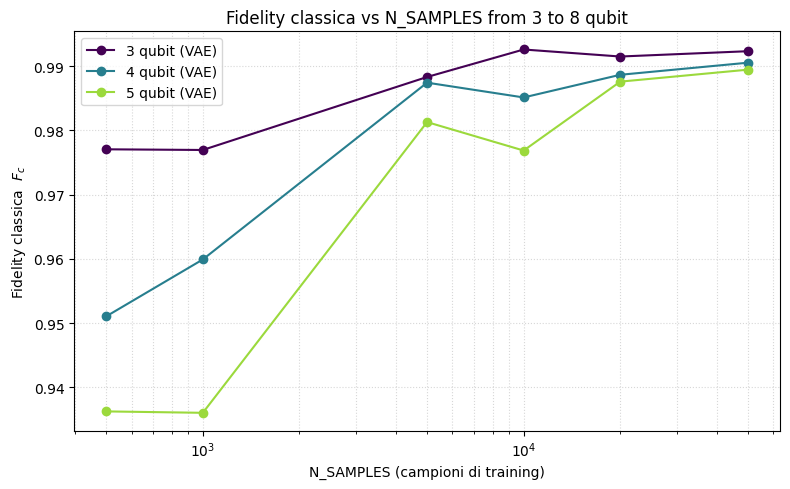

In [11]:
plot_fidelity_vs_samples(history, results)

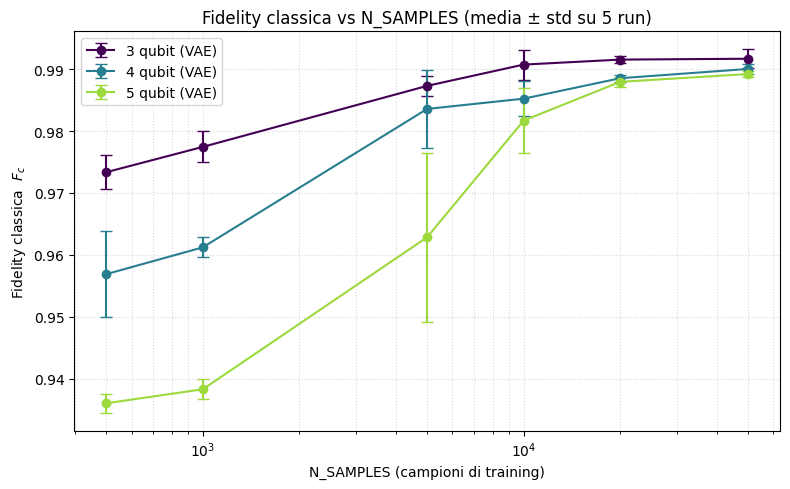

,n_qubits,n_samples,Fc_mean,Fc_std,Fc_train_mean,Fc_train_std
0,3,500,0.973351,0.002738,0.974082,0.0
1,3,1000,0.977437,0.002494,0.985954,0.0
2,3,5000,0.987282,0.001650,0.998013,0.0
3,3,10000,0.990720,0.002409,0.999158,0.0
4,3,20000,0.991525,0.000609,0.999518,0.0
5,3,50000,0.991664,0.001491,0.999811,0.0
6,4,500,0.956899,0.006932,0.868592,0.0
7,4,1000,0.961225,0.001635,0.939375,0.0
8,4,5000,0.983562,0.006235,0.991020,0.0
9,4,10000,0.985220,0.002842,0.995931,0.0


In [5]:
# Carica i risultati di run_1 ... run_N, calcola media e std della fidelity
# classica su tutte le run e plotta F_c vs N_SAMPLES con barre d'errore,
# una curva per ogni numero di qubit.
N_RUNS = 5

# Concatena i CSV di tutte le run in un unico DataFrame
runs = []
for i in range(1, N_RUNS + 1):
    csv_path = RESULTS_ROOT / f"run_{i}" / "vae_training_results.csv"
    df_i = pd.read_csv(csv_path)
    df_i["run"] = i
    runs.append(df_i)
all_runs = pd.concat(runs, ignore_index=True)

# Media e deviazione standard di Fc (e Fc_train) sulle run, per ogni (n_qubits, n_samples)
stats = (
    all_runs
    .groupby(["n_qubits", "n_samples"])
    .agg(Fc_mean=("Fc", "mean"), Fc_std=("Fc", "std"),
         Fc_train_mean=("Fc_train", "mean"), Fc_train_std=("Fc_train", "std"))
    .reset_index()
)

# Plot: fidelity media vs N_SAMPLES con barre d'errore (std), una curva per numero di qubit
plt.figure(figsize=(8, 5))
qubit_list = sorted(stats["n_qubits"].unique())
colors = plt.cm.viridis(np.linspace(0, 0.85, len(qubit_list)))

for color, q in zip(colors, qubit_list):
    sub = stats[stats["n_qubits"] == q].sort_values("n_samples")
    plt.errorbar(sub["n_samples"], sub["Fc_mean"], yerr=sub["Fc_std"],
                 fmt='-o', color=color, capsize=4, label=f'{q} qubit (VAE)')

plt.xscale('log')
plt.xlabel('N_SAMPLES (campioni di training)')
plt.ylabel('Fidelity classica  $F_c$')
plt.title(f'Fidelity classica vs N_SAMPLES (media ± std su {N_RUNS} run)')
plt.grid(True, which='both', ls=':', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

stats